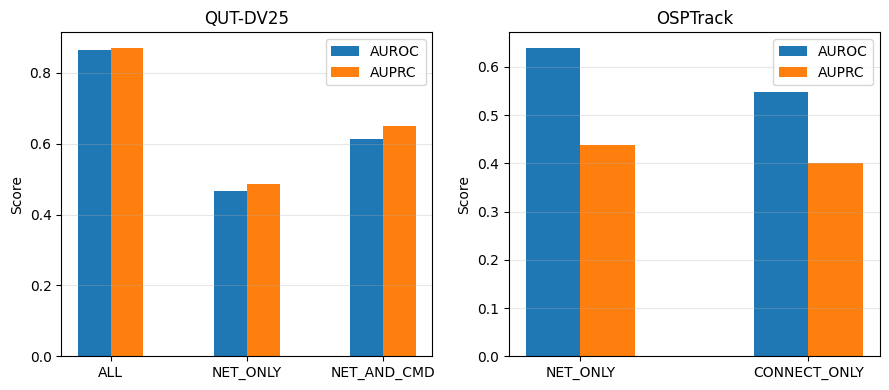

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ----------------------------
# 1) Load data
# ----------------------------
qut_path = Path("./ablate_qut_hunt/qut_hunt_rarity.tsv")
osp_path = Path("./ablate_osp_hunt/osp_hunt_rarity.tsv")

qut = pd.read_csv(qut_path, sep="\t")
osp = pd.read_csv(osp_path, sep="\t")

ETYPE_SCOPE = {
    "": "ALL",
    "PROC|DNS_QUERY|NET,PROC|RESOLVE|NET,PROC|CONNECT|NET": "NET_ONLY",
    "PROC|CONNECT|NET": "CONNECT_ONLY",
    "PROC|DNS_QUERY|NET,PROC|RESOLVE|NET,PROC|CONNECT|NET,PROC|EXEC|CMD": "NET_AND_CMD",
}


def add_scope(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    etypes = out["rarity_etypes"].fillna("").astype(str)
    out["scope"] = etypes.map(lambda value: ETYPE_SCOPE.get(value, value))
    return out


qut = add_scope(qut)
osp = add_scope(osp)

qut_sel = qut[(qut["rarity_lambda"] == 0.5) & (qut["rarity_idf_cap"] == 0.0)].copy()
osp_sel = osp[(osp["rarity_lambda"] == 0.3) & (osp["rarity_idf_cap"] == 2.0)].copy()

qut_order = ["ALL", "NET_ONLY", "NET_AND_CMD"]
osp_order = ["NET_ONLY", "CONNECT_ONLY"]


def prepare_scope_summary(df: pd.DataFrame, order: list[str]) -> pd.DataFrame:
    rows = []
    base_auroc = float(df["base_auroc"].iloc[0])
    base_auprc = float(df["base_auprc"].iloc[0])
    for scope in order:
        cur = df[df["scope"] == scope]
        if cur.empty:
            continue
        rows.append(
            {
                "scope": scope,
                "rarity_auroc": float(cur["rarity_auroc"].iloc[0]),
                "rarity_auprc": float(cur["rarity_auprc"].iloc[0]),
                "base_auroc": base_auroc,
                "base_auprc": base_auprc,
            }
        )
    return pd.DataFrame(rows)


qut_plot = prepare_scope_summary(qut_sel, qut_order)
osp_plot = prepare_scope_summary(osp_sel, osp_order)

# -----------------------------------
# Plot
# -----------------------------------
BAR_WIDTH = 0.24
fig, axes = plt.subplots(1, 2, figsize=(7.5, 4), sharey=False)

for ax, df_plot, title in [
    (axes[0], qut_plot, "QUT-DV25"),
    (axes[1], osp_plot, "OSPTrack"),
]:
    x = range(len(df_plot))

    ax.bar([i - BAR_WIDTH / 2 for i in x], df_plot["rarity_auroc"], width=BAR_WIDTH, label="AUROC")
    ax.bar([i + BAR_WIDTH / 2 for i in x], df_plot["rarity_auprc"], width=BAR_WIDTH, label="AUPRC")

    ax.set_xticks(list(x))
    ax.set_xticklabels(df_plot["scope"])
    ax.set_title(title)
    ax.set_ylabel("Score")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

# plt.suptitle("Relation-type scope comparison for rarity reranking", y=1.02)
plt.tight_layout()
plt.show()